<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/Session_11%2612.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Preprocessing Techniques


**EDA** - Exploratory Data Analysis

Manipulation , Data Analysis

-No null values                                           
-No duplicate values                                      
-No nan (Not a number)                                    
-No extremevalues, outliers which is also called as Anomalies                                                 
-No missing values


preprocessing - Transformation of data which suits the standards to train with any ML algorithms for better accuracy of the ML model.

Preprocessing techniques:
* Binarisation
* Normalisation
* Winsoristion
* Dicretation
* Imputation technique
* One hot encoding
* Label encoding

Continues datatypes - variable It can be measured (height,weight,time,temperature)
discret datatypes - variable It can be count (number of bike ,car,people etc)

**Binarisation** in data analysis
**Imagine this** : You have a list  of students and thier scores on a test.Instead of seeing the exact scores (like 75, 92, 60, 88), you might just want to know if they passed or failed.Binarization helps you achieve this of transformation.

**What is Binarization?**

 In simple terms,binarization is the process of transforming a continuous or multi-valued categoricalvariable into binary variable. 'Binary' means it has only **two possible values**,typically 0 and 1.think of it as converting something into a 'yes/no' or 'true/false' representation.

 **The Key Ingredient:** A Threshold
 To perform binarization, you need to decide on a threshold.**This threshold acts like a dividing line**.Valves above the threshold get one binary value(ussally 1), and values below the threshold get the other (usually 0)

 let's go back to our student scores examples:
 Suppose the passing score for the test is 70. We can use 70 as our threshold for binarizaton:

  * If a student's score is 70 or above,we can assign them a binary value of 1(representing 'passed')
  * if a student's score is below 70, we can assign them a binary value of 0 (representing 'failed')

  So,the original scores (75,92,60,88) would be transformed into binary values(1,1,0,1).

  **Why Use Binarization?**
  
  You might be wondering , Why would i want o simlify my data like this?'here are a reasons:
   
  * Simplifying Complex Data : Sometimes,having too many different valves in a variable can make analysis and modeling more complex. Binarization reduces this complexity.
  * focusing on a specfic condition : You might be specifically interested in whwther a certain condition is met (e.g did the customer spend more than $100? was the website visited? , was the patient diagnosed with the disease?).Binarization directly answers these yes/no questions.
  * Fearture Engineering for Certain models : Some machine learning algorithms work better or require binary input features.For example, certain rule-based systems or older algorithms might prefer binary data.
  * creating indicator variables: Binarization can create indicator variables(also known as dummy variables, though that term is often uesd for categorical data).These indicators can signal the presence or absence of a specfic characterristic.
  * Data Privacy (in some cases) :In certain binarizing data (with a carefully chosen threshold) might offer a degree of privacy by obscuring the exact values
  
         

**Examples in Different Scenarios:
* E-commerce : Customer spending:
    * Threshold:$100

    * Spending > $100 becomes 1(high Spender)

    * Spending <= $100 becomes 0(low spender)
* Website Analytics :session duration:
    * threshold: 5 minutes

    * Session >= 5 minutes becomes 1 (Engaged User)

    * session < 5 minutes becomes 0 (Bounced User)

* Healthcare : Blood pressure:
    * treshold: 140 mmHg (systolic)

    * blood pressure >= 140 becomes 1 (High Blood pressure)

    * blood pressure < 140 becomes 0 (normal Blood pressure)

* Sensor Data: Temperature:

* Choosing the Right Threshold: The most crucial step in binarization is selecting an appropriate threshold. This choice can significantly impact the results of your analysis.the threshold should be meaningful in the context of your data and the problem you're trying to solve. You might use domain knowledge , statistical analysis, or the goals of your project to determine the best threshold.


   patient  cholesterol  blood_pressure  BMI  Exercise_hours
0       P1          190             120   22               5
1       P2          240             145   29               2
2       P3          210             135   31               1
3       P4          180             110   24               6
4       P5          260             160   35               0
5       P6          220             138   28               3
6       P7          195             125   26               4
7       P8          250             155   33               1
8       P9          170             115   23               7
9      P10          205             130   27               5
10     P11          230             142   30               2
11     P12          185             118   25               6 Original Dataframe
------------------------------------------------------------------------------------------
   patient  cholesterol  blood_pressure  BMI  Exercise_hours  \
0       P1          190          

/tmp/ipykernel_910/407591164.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['chorlestrol_high'], ax=axes[0,1], palette='pastel')
/tmp/ipykernel_910/407591164.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['blood_pressure_high'], ax=axes[1,1], palette='magma')
/tmp/ipykernel_910/407591164.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['BMI_high'], ax=axes[2,1], palette='coolwarm')
/tmp/ipykernel_910/407591164.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

Text(0.5, 1.0, 'Exercise Hours (Binary with threshold)')

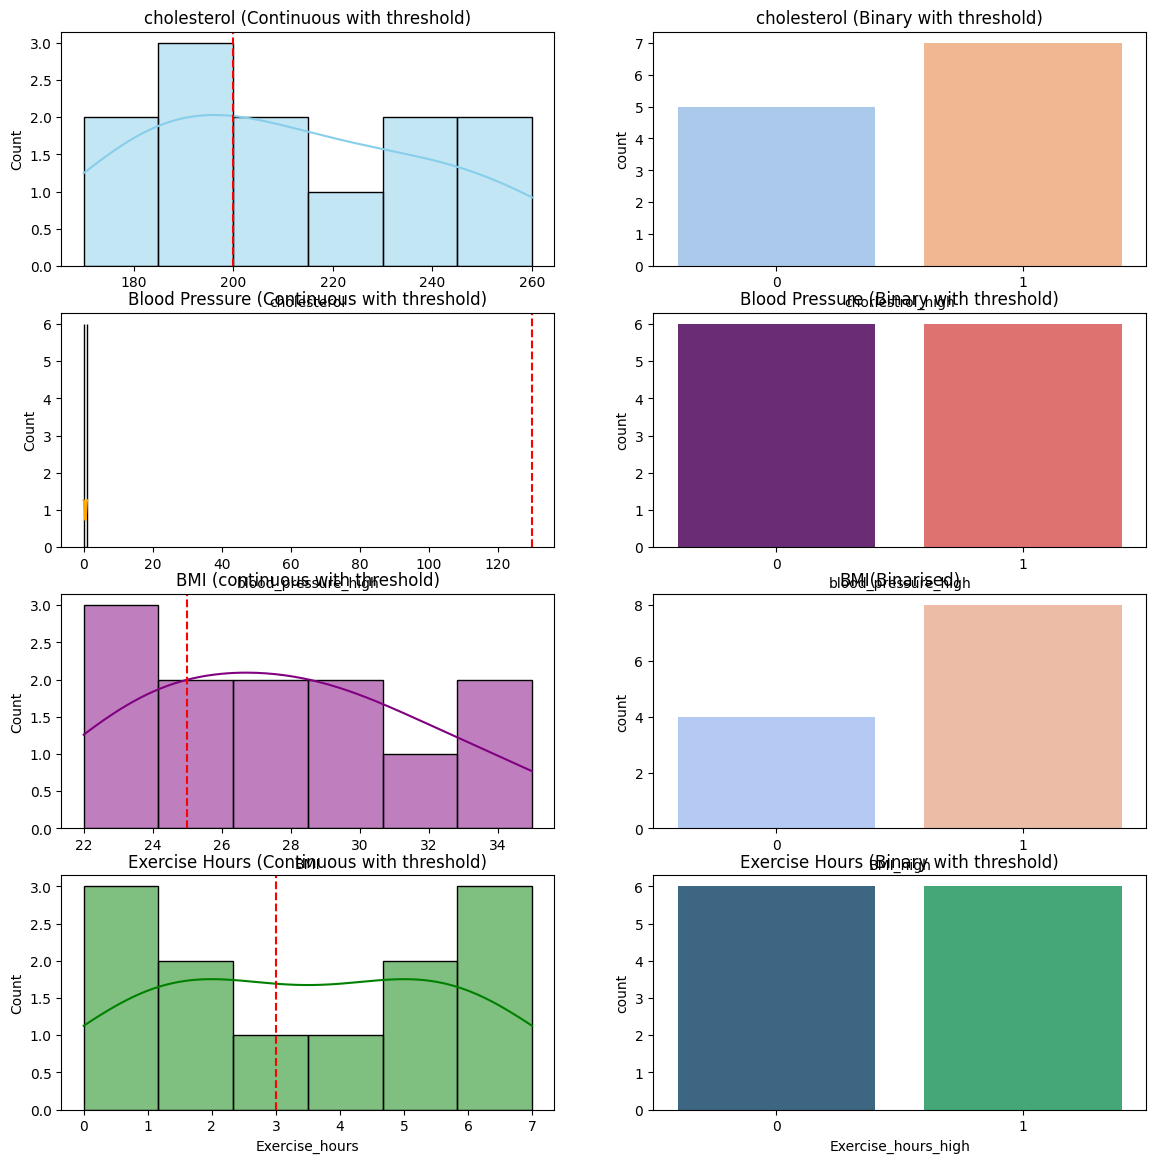

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Binarizer

data = {
      'patient':[f'P{i}' for i in range(1,13)],
      'cholesterol':[190,240,210,180,260,220,195,250,170,205,230,185],
      'blood_pressure':[120,145,135,110,160,138,125,155,115,130,142,118],
      'BMI':[22,29,31,24,35,28,26,33,23,27,30,25],
      'Exercise_hours': [5,2,1,6,0,3,4,1,7,5,2,6]
      }

df = pd.DataFrame(data)
print(df,'Original Dataframe')

binarizer_chol = Binarizer(threshold=200)
binarizer_bp = Binarizer(threshold=130)
binarizer_bmi = Binarizer(threshold=25)
binarizer_ex = Binarizer(threshold=3)
print('------'*15)
df['chorlestrol_high'] = binarizer_chol.fit_transform(df[['cholesterol']])
df['blood_pressure_high'] = binarizer_bp.fit_transform(df[['blood_pressure']])
df['BMI_high'] = binarizer_bmi.fit_transform(df[['BMI']])
df['Exercise_hours_high'] = binarizer_ex.fit_transform(df[['Exercise_hours']])

print(df,'Binarized Dataframe')

### _______________________Step 3: visualization _____________________________

fig,axes = plt.subplots(4,2,figsize=(14,14))

#cholesterol
sns.histplot(df['cholesterol'],bins=6, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].axvline(200,color='red',linestyle='--',linewidth=1.5)
axes[0,0].set_title('cholesterol (Continuous with threshold)')

sns.countplot(x=df['chorlestrol_high'], ax=axes[0,1], palette='pastel')
axes[0,1].set_title('cholesterol (Binary with threshold)')

#blood pressure
sns.histplot(df['blood_pressure_high'], bins=6, kde=True, ax=axes[1,0],color='orange')
axes[1,0].axvline(130, color='red',linestyle='--',linewidth=1.5)
axes[1,0].set_title('Blood Pressure (Continuous with threshold)')

sns.countplot(x=df['blood_pressure_high'], ax=axes[1,1], palette='magma')
axes[1,1].set_title('Blood Pressure (Binary with threshold)')

#BMI
sns.histplot(df['BMI'], bins=6, kde=True, ax=axes[2,0], color='purple')
axes[2,0].axvline(25, color ='red',linestyle='--', linewidth=1.5)
axes[2,0].set_title('BMI (continuous with threshold)')

sns.countplot(x=df['BMI_high'], ax=axes[2,1], palette='coolwarm')
axes[2,1].set_title('BMI(Binarised)')

#Exercise hour
sns.histplot(df['Exercise_hours'],bins=6, kde=True, ax=axes[3,0],color='green')
axes[3,0].axvline(3, color='red',linestyle='--',linewidth=1.5)
axes[3,0].set_title('Exercise Hours (Continuous with threshold)')

sns.countplot(x=df['Exercise_hours_high'], ax=axes[3,1], palette='viridis')
axes[3,1].set_title('Exercise Hours (Binary with threshold)')

#kde - Kernel Density Estimation




#What is Normalization?
Normalization is a technique used to rescale numerical data to a standard range, typically between 0 and 1, or sometimes between -1 and 1. The goal is to bring all the numerical features to a similar scale without distorting the differences in the ranges of values.


  Student  AGE  EXAM_Score
0       A   18          75
1       B   22          88
2       C   20          67
3       D   24          95
4       E   19          80

Normalized Dataset:
   Student       AGE  EXAM_Score
0       A  0.000000    0.285714
1       B  0.666667    0.750000
2       C  0.333333    0.000000
3       D  1.000000    1.000000
4       E  0.166667    0.464286

Z-score standardized Dataset:
   Student       AGE  EXAM_Score
0       A -1.079591   -0.548867
1       B  0.581318    0.640345
2       C -0.249136   -1.280690
3       D  1.411773    1.280690
4       E -0.664364   -0.091478


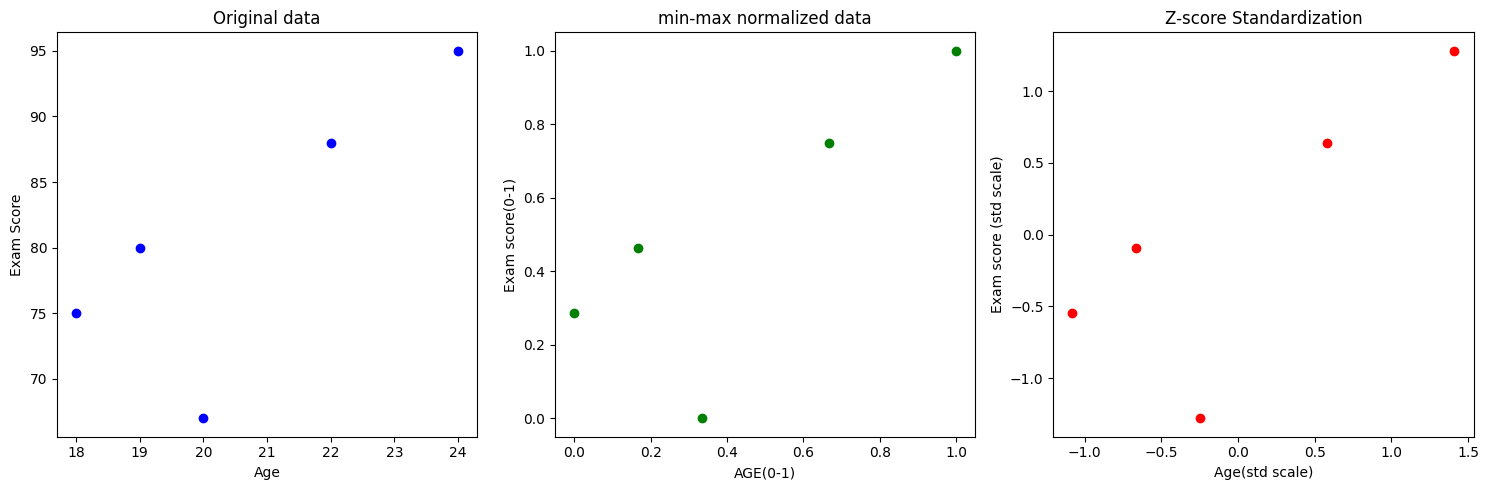

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = {
        'Student': ['A','B','C','D','E'],
        'AGE':[18,22,20,24,19],
        'EXAM_Score':[75,88,67,95,80]
}

df = pd.DataFrame(data)
print(df)

# Min - Max normalizartion

df_norm = df.copy()
for col in ['AGE','EXAM_Score']:
    min_val = df[col].min()
    max_val = df[col].max()
    df_norm[col] = (df[col] - min_val) / (max_val - min_val)
print('\nNormalized Dataset:\n', df_norm)

#__________________Z-score Standardization______________________

df_zscore = df.copy()
for col in [ 'AGE','EXAM_Score']:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df_zscore[col] = (df[col] - mean_val)/std_val
print('\nZ-score standardized Dataset:\n', df_zscore)

#_________________________plot comparison______________________________

fig, axes = plt.subplots(1,3,figsize=(15,5))

#Original
axes[0].scatter(df['AGE'],df['EXAM_Score'],color='blue')
axes[0].set_title('Original data')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Exam Score')

#Min-Max Normalization
axes[1].scatter(df_norm['AGE'],df_norm['EXAM_Score'],color='green')
axes[1].set_title('min-max normalized data')
axes[1].set_xlabel('AGE(0-1)')
axes[1].set_ylabel('Exam score(0-1)')

#Zscore
axes[2].scatter(df_zscore['AGE'],df_zscore['EXAM_Score'],color='red')
axes[2].set_title('Z-score Standardization')
axes[2].set_xlabel('Age(std scale)')
axes[2].set_ylabel('Exam score (std scale)')

plt.tight_layout()
plt.show()



